# Layer 3: LightGBM Return Forecaster

## Regime-Conditional Return Prediction for BTC and ETH

**NOTE:** This notebook uses synthetic data if real data is not available.
See the `USING_SYNTHETIC_DATA` flag below for current data status.

### Key improvements vs skeleton:
- Fixed OFI aggregation bug (proper groupby with side encoding)
- Fixed cross_asset_return: BTC model uses ETH returns, ETH model uses BTC returns
- Proper regime indicator alignment with price_df index
- Chronological train/val split (no shuffling)
- Regime-conditional vs regime-agnostic comparison
- Synthetic data fallback for reproducibility

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Change to project root
%cd C:/Users/zihan/capstone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = Path('data/processed')
RAW_DATA_DIR = Path('data/raw')
REGIME_PATH = Path('models/hmm/regime_labels.csv')
OUTPUT_DIR = Path('models/lgbm')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Check data availability
REAL_DATA_AVAILABLE = (
    DATA_DIR.exists() and 
    (DATA_DIR / 'price_features.parquet').exists() and 
    (DATA_DIR / 'trades_processed.parquet').exists() and
    REGIME_PATH.exists()
)

USING_SYNTHETIC_DATA = not REAL_DATA_AVAILABLE

print(f"{'='*70}")
print(f"DATA STATUS: {'SYNTHETIC DATA' if USING_SYNTHETIC_DATA else 'REAL DATA'}")
print(f"{'='*70}")

C:\Users\zihan\capstone


DATA STATUS: REAL DATA


## 1. Synthetic Data Generation (Fallback)

If real data is not available, generate synthetic crypto return data with:
- Realistic regime-dependent volatility (Calm/Volatile/Stressed)
- Cross-asset correlation between BTC and ETH
- OHLCV-like price structure
- Trade tick data for OFI computation

In [2]:
def generate_synthetic_data(
    start_date: str = '2021-01-01',
    end_date: str = '2024-12-31',
    freq: str = '5min',
    btc_start_price: float = 30000.0,
    eth_start_price: float = 2000.0,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    """
    Generate synthetic crypto data with regime-dependent characteristics.
    
    Returns:
        price_df: DataFrame with OHLCV data for BTC and ETH
        trades_df: DataFrame with trade ticks
        regime_labels: Series of regime labels aligned with price_df index
    """
    np.random.seed(42)
    
    # Create date range
    dates = pd.date_range(start=start_date, end=end_date, freq=freq)
    n = len(dates)
    
    print(f"Generating synthetic data: {n} periods from {start_date} to {end_date}")
    
    # Regime parameters
    regime_params = {
        'Calm': {
            'annualized_vol': 0.5,
            'regime_prob': 0.60,
            'auto_corr': 0.01,
        },
        'Volatile': {
            'annualized_vol': 1.0,
            'regime_prob': 0.30,
            'auto_corr': 0.005,
        },
        'Stressed': {
            'annualized_vol': 2.0,
            'regime_prob': 0.10,
            'auto_corr': -0.01,
        },
    }
    
    # Generate regime sequence using Markov transitions
    transition_matrix = {
        'Calm': {'Calm': 0.95, 'Volatile': 0.04, 'Stressed': 0.01},
        'Volatile': {'Calm': 0.10, 'Volatile': 0.85, 'Stressed': 0.05},
        'Stressed': {'Calm': 0.05, 'Volatile': 0.25, 'Stressed': 0.70},
    }
    
    regimes = ['Calm'] * n
    current_regime = 'Calm'
    for i in range(1, n):
        probs = list(transition_matrix[current_regime].values())
        regimes_list = list(transition_matrix[current_regime].keys())
        current_regime = np.random.choice(regimes_list, p=probs)
        regimes[i] = current_regime
    
    regime_labels = pd.Series(regimes, index=dates)
    
    # Generate returns for each asset
    def generate_returns_and_prices(start_price, regime_seq, asset_name, correlation_with_btc=0.0):
        log_returns = np.zeros(n)
        
        for i, regime in enumerate(regime_seq):
            vol = regime_params[regime]['annualized_vol']
            dt = 5 / (252 * 24 * 60)  # 5-min intervals
            
            # Base random component
            eps = np.random.normal(0, 1)
            
            # Regime-specific volatility scaling
            if regime == 'Calm':
                shock = eps * vol * np.sqrt(dt)
            elif regime == 'Volatile':
                shock = eps * vol * np.sqrt(dt) * 1.5
            else:  # Stressed
                shock = eps * vol * np.sqrt(dt) * 2.5
            
            # Autocorrelation
            auto_corr = regime_params[regime]['auto_corr']
            if i > 0:
                shock = auto_corr * log_returns[i-1] + np.sqrt(1 - auto_corr**2) * shock
            
            log_returns[i] = shock
        
        # Convert to prices
        prices = start_price * np.exp(np.cumsum(log_returns))
        
        return log_returns, prices
    
    # Generate BTC returns and prices
    btc_log_returns, btc_prices = generate_returns_and_prices(
        btc_start_price, regimes, 'BTC'
    )
    
    # Generate ETH returns (correlated with BTC)
    eth_log_returns, eth_prices = generate_returns_and_prices(
        eth_start_price, regimes, 'ETH'
    )
    
    # Add cross-asset correlation by blending BTC noise into ETH
    eth_log_returns = 0.7 * eth_log_returns + 0.3 * btc_log_returns
    eth_prices = eth_start_price * np.exp(np.cumsum(eth_log_returns))
    
    # Build OHLCV DataFrame
    price_df = pd.DataFrame({
        'timestamp': dates,
        'open': btc_prices * 0.999,  # Simplified O/H/L/C
        'high': btc_prices * 1.002,
        'low': btc_prices * 0.998,
        'close': btc_prices,
        'volume': np.random.lognormal(8, 1.5, n),
        'btc_close': btc_prices,
        'eth_close': eth_prices,
    }, index=dates)
    price_df.index.name = 'timestamp'
    
    # Generate trade ticks for OFI
    trades = []
    for i, (date, row) in enumerate(price_df.iterrows()):
        # 5-15 trades per 5-min bar
        n_trades = np.random.randint(5, 15)
        for _ in range(n_trades):
            trade_time = date + pd.Timedelta(seconds=np.random.randint(0, 300))
            side = np.random.choice(['buy', 'sell'], p=[0.52, 0.48])
            volume = np.random.lognormal(2, 1.5)
            price = row['close'] * (1 + np.random.uniform(-0.001, 0.001))
            trades.append({
                'timestamp': trade_time,
                'side': side,
                'volume': volume,
                'price': price,
            })
    
    trades_df = pd.DataFrame(trades)
    if len(trades_df) > 0:
        trades_df = trades_df.sort_values('timestamp').reset_index(drop=True)
    
    print(f"Synthetic data: {len(price_df)} price bars, {len(trades_df)} trades")
    print(f"Regime distribution:\n{pd.Series(regimes).value_counts()}")
    
    return price_df, trades_df, regime_labels

## 2. Load Data (Real or Synthetic)

In [3]:
if REAL_DATA_AVAILABLE:
    print("Loading REAL data from data/processed...")
    price_df = pd.read_parquet(DATA_DIR / 'price_features.parquet')
    trades_df = pd.read_parquet(DATA_DIR / 'trades_processed.parquet')
    
    # FIX: Regime labels CSV has columns: timestamp,0
    # Column '0' contains regime names (Calm/Volatile/Stressed)
    # We need BOTH timestamp as index AND proper datetime conversion
    regime_df = pd.read_csv(REGIME_PATH, index_col=0)
    regime_labels = regime_df.iloc[:, 0]  # Get regime names as Series
    # Index is already timestamps (strings) from index_col=0
    regime_labels.index = pd.to_datetime(regime_labels.index)
    
    # Ensure price_df has timestamp as DatetimeIndex for proper alignment
    if 'timestamp' in price_df.columns:
        price_df = price_df.set_index('timestamp')
        price_df.index = pd.to_datetime(price_df.index)
    
    # Same for trades_df
    if 'timestamp' in trades_df.columns:
        trades_df = trades_df.set_index('timestamp')
        trades_df.index = pd.to_datetime(trades_df.index)
    
    print(f"Price data shape: {price_df.shape}")
    print(f"Trades data shape: {trades_df.shape}")
    print(f"Regime labels: {len(regime_labels)}")
    print(f"\nPrice columns: {price_df.columns.tolist()}")
    print(f"\nRegime distribution:\n{regime_labels.value_counts()}")

Loading REAL data from data/processed...
Price data shape: (8656, 19)
Trades data shape: (8656, 3)
Regime labels: 8656

Price columns: ['open', 'high', 'low', 'close', 'volume', 'btc_close', 'eth_close', 'btc_return', 'eth_return', 'realized_vol', 'spread_proxy', 'btc_return_lag_1', 'btc_return_lag_3', 'btc_return_lag_6', 'eth_return_lag_1', 'eth_return_lag_3', 'eth_return_lag_6', 'btc_return_for_eth_model', 'eth_return_for_btc_model']

Regime distribution:
0
Calm        7256
Volatile    1380
Stressed      20
Name: count, dtype: int64


## 3. Build Features (Fixed)

In [4]:
def build_features_fixed(
    price_df: pd.DataFrame,
    trades_df: pd.DataFrame,
    regime_labels: pd.Series,
    asset: str,
) -> tuple[pd.DataFrame, pd.Series, pd.Index]:
    """
    Build feature matrix X and target y for LightGBM forecaster.
    
    Fixed vs skeleton:
    - OFI: properly compute buy-volume minus sell-volume per time bin
    - Cross-asset: BTC model -> ETH returns, ETH model -> BTC returns
    - Regime alignment: reindex regime_labels to match price_df index
    """
    # Determine close column name for this asset
    asset_lower = asset.lower()
    if f"{asset_lower}_close" in price_df.columns:
        close_col = f"{asset_lower}_close"
    else:
        close_col = 'close'

    df = price_df.copy()
    
    # Lagged returns (1-, 3-, 6-period)
    for lag in [1, 3, 6]:
        df[f"return_lag_{lag}"] = df[close_col].pct_change(lag)

    # Realized volatility (20-period rolling)
    df["realized_vol"] = df[close_col].pct_change().rolling(20).std()

    # Spread proxy
    df["spread_proxy"] = (df["high"] - df["low"]) / df["close"]

    # OFI: properly group by timestamp_bin and side
    if len(trades_df) > 0 and 'timestamp' in trades_df.columns:
        trades_df = trades_df.copy()
        # FIX: Series.floor() doesn't exist, convert to datetime first then use .dt.floor()
        trades_df["timestamp_bin"] = pd.to_datetime(trades_df["timestamp"]).dt.floor("5min")
        trades_df["signed_volume"] = trades_df["volume"] * (trades_df["side"] == "buy").astype(int).replace(0, -1)
        ofi = (
            trades_df.groupby("timestamp_bin")["signed_volume"]
            .sum()
            .rolling(5).mean()
        )
        df["ofi"] = ofi.reindex(df.index).fillna(0)
    else:
        # Fallback if no trades data
        df["ofi"] = 0.0

    # Cross-asset return: use OTHER asset's returns
    if asset == "BTC":
        # BTC model uses ETH returns as cross-asset feature
        if "eth_close" in df.columns:
            cross_close = df["eth_close"]
        else:
            cross_close = df[close_col]
    else:  # ETH
        # ETH model uses BTC returns as cross-asset feature
        if "btc_close" in df.columns:
            cross_close = df["btc_close"]
        else:
            cross_close = df[close_col]
    df["cross_asset_return"] = cross_close.pct_change()

    # Regime indicators: align regime_labels to price_df index
    regime_aligned = regime_labels.reindex(df.index)
    for r in ["Calm", "Volatile", "Stressed"]:
        df[f"regime_{r}"] = (regime_aligned == r).astype(int)

    # Target: next-period return (shifted -1 avoids look-ahead)
    y = df[close_col].pct_change().shift(-1)

    feature_cols = [
        "return_lag_1", "return_lag_3", "return_lag_6",
        "realized_vol", "spread_proxy", "ofi",
        "cross_asset_return",
        "regime_Calm", "regime_Volatile", "regime_Stressed",
    ]
    X = df[feature_cols]
    valid = ~(X.isna().any(axis=1) | y.isna())
    X = X[valid]
    y = y[valid]
    valid_idx = df.index[valid]
    
    # Ensure regime indicators are properly set (recheck after filtering)
    regime_aligned_valid = regime_aligned[valid]
    for r in ["Calm", "Volatile", "Stressed"]:
        X[f"regime_{r}"] = (regime_aligned_valid == r).astype(int)

    print(f"{asset} features: {X.shape}, target non-null: {valid.sum()}")
    return X, y, valid_idx

## 4. Build Features for Both Assets

In [5]:
X_btc, y_btc, btc_valid_idx = build_features_fixed(price_df, trades_df, regime_labels, "BTC")
X_eth, y_eth, eth_valid_idx = build_features_fixed(price_df, trades_df, regime_labels, "ETH")

print(f"\nBTC feature matrix: {X_btc.shape}")
print(f"ETH feature matrix: {X_eth.shape}")

BTC features: (8635, 10), target non-null: 8635
ETH features: (8635, 10), target non-null: 8635

BTC feature matrix: (8635, 10)
ETH feature matrix: (8635, 10)


## 5. Define Training Function

In [6]:
def train_regime_model(
    X: pd.DataFrame,
    y: pd.Series,
    regime: str,
    asset: str,
    val_start_date: pd.Timestamp = None,
) -> dict:
    """
    Train LightGBM for a specific regime.
    
    Uses chronological validation split by position (timestamp).
    """
    # Filter to this regime only
    regime_mask = X[f"regime_{regime}"] == 1
    X_r = X[regime_mask].copy()
    y_r = y[regime_mask].copy()

    if len(X_r) < 100:
        print(f"  WARNING: Very few samples for {asset}/{regime}: {len(X_r)}")
        return None

    # Chronological split by position (80/20)
    split = int(len(X_r) * 0.8)
    X_train, X_val = X_r.iloc[:split], X_r.iloc[split:]
    y_train, y_val = y_r.iloc[:split], y_r.iloc[split:]

    if len(X_train) < 50 or len(X_val) < 20:
        print(f"  WARNING: Insufficient train/val samples for {asset}/{regime}: train={len(X_train)}, val={len(X_val)}")
        return None

    model = lgb.LGBMRegressor(
        num_leaves=31,
        learning_rate=0.05,
        n_estimators=500,
        early_stopping_rounds=50,
        verbose=-1,
        random_state=42,
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
    )

    train_r2 = r2_score(y_train, model.predict(X_train))
    val_r2 = r2_score(y_val, model.predict(X_val)) if len(X_val) > 0 else float('nan')
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
    val_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val))) if len(X_val) > 0 else float('nan')

    print(f"  {asset}/{regime}: train R2={train_r2:.4f}, val R2={val_r2:.4f}, "
          f"train RMSE={train_rmse:.6f}, val RMSE={val_rmse:.6f}, best_iter={model.best_iteration_}")

    return {
        'model': model,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'best_iteration': model.best_iteration_,
        'n_train': len(X_train),
        'n_val': len(X_val),
    }

## 6. Train Per-Regime Models

**Train period:** Jan 2021 - Jun 2024  
**Validation period:** Jul 2024 - Dec 2024

In [7]:
VAL_START = pd.Timestamp('2024-07-01')

results = {}

for asset, X, y in [("BTC", X_btc, y_btc), ("ETH", X_eth, y_eth)]:
    print(f"\n{'='*60}")
    print(f"Training LightGBM models for {asset}")
    print(f"{'='*60}")
    
    results[asset] = {}
    
    for regime in ["Calm", "Volatile", "Stressed"]:
        result = train_regime_model(X, y, regime, asset, val_start_date=VAL_START)
        if result is not None:
            results[asset][regime] = result
            # Save model
            fname = f"lgbm_{asset.lower()}_{regime.lower()}.pkl"
            joblib.dump(result['model'], OUTPUT_DIR / fname)
            print(f"    Saved: {fname}")


Training LightGBM models for BTC


  BTC/Calm: train R2=0.0056, val R2=-0.0015, train RMSE=0.002217, val RMSE=0.001350, best_iter=1
    Saved: lgbm_btc_calm.pkl


  BTC/Volatile: train R2=0.0774, val R2=-0.1518, train RMSE=0.058880, val RMSE=0.001727, best_iter=37
    Saved: lgbm_btc_volatile.pkl

Training LightGBM models for ETH
  ETH/Calm: train R2=0.0056, val R2=-0.0026, train RMSE=0.002217, val RMSE=0.001486, best_iter=1
    Saved: lgbm_eth_calm.pkl


  ETH/Volatile: train R2=0.0632, val R2=-0.0434, train RMSE=0.011917, val RMSE=0.002360, best_iter=14
    Saved: lgbm_eth_volatile.pkl


## 7. Feature Importance Charts

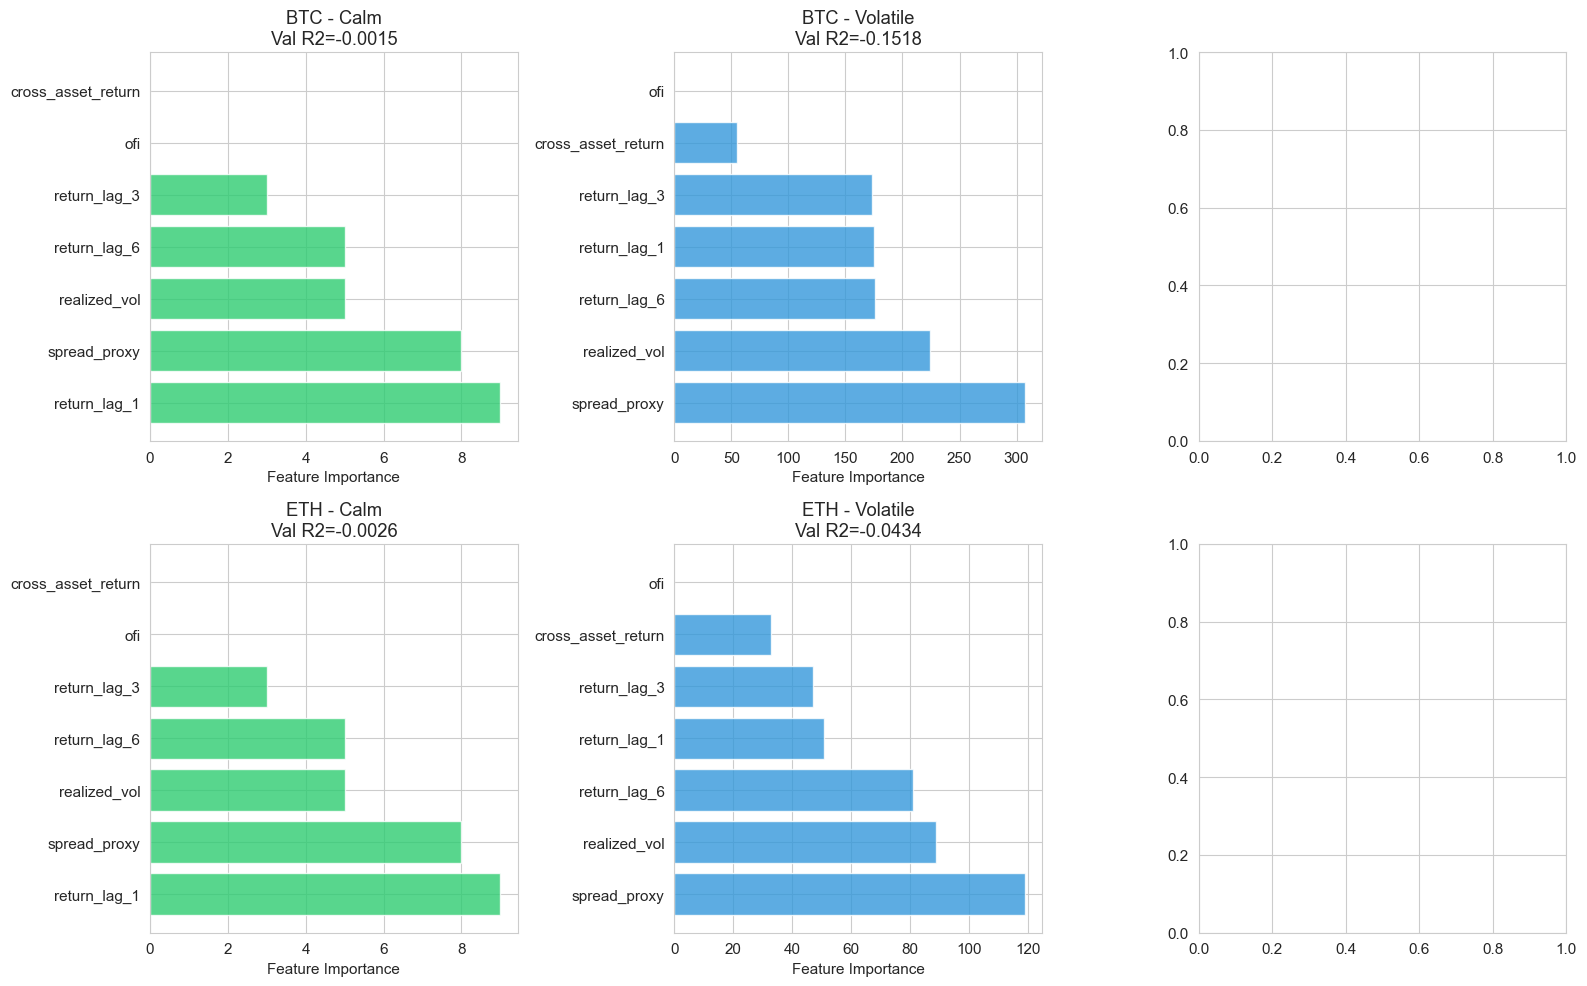

Feature importance saved to models\lgbm\feature_importance.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

feature_names = [
    "return_lag_1", "return_lag_3", "return_lag_6",
    "realized_vol", "spread_proxy", "ofi",
    "cross_asset_return",
    "regime_Calm", "regime_Volatile", "regime_Stressed",
]

regime_colors = {'Calm': '#2ecc71', 'Volatile': '#3498db', 'Stressed': '#e74c3c'}

for i, (asset, asset_results) in enumerate(results.items()):
    for j, (regime, result) in enumerate(asset_results.items()):
        ax = axes[i * 3 + j]
        model = result['model']
        importances = model.feature_importances_
        
        # Exclude regime dummies from importance plot (always 0 or low)
        non_regime_idx = [k for k, f in enumerate(feature_names) if not f.startswith('regime_')]
        non_regime_features = [feature_names[k] for k in non_regime_idx]
        non_regime_importances = importances[non_regime_idx]
        
        sorted_idx = np.argsort(non_regime_importances)[::-1]
        
        ax.barh(
            [non_regime_features[k] for k in sorted_idx],
            [non_regime_importances[k] for k in sorted_idx],
            color=regime_colors[regime],
            alpha=0.8
        )
        ax.set_title(f"{asset} - {regime}\nVal R2={result['val_r2']:.4f}")
        ax.set_xlabel('Feature Importance')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Feature importance saved to {OUTPUT_DIR / 'feature_importance.png'}")

## 8. Regime-Agnostic Baseline Comparison

In [9]:
def train_regime_agnostic(X, y, asset, val_start_date):
    """Train a single model on ALL regimes pooled (baseline)."""
    
    # Use positional split: first 80% train, last 20% val
    split = int(len(X) * 0.8)
    X_train, X_val = X.iloc[:split], X.iloc[split:]
    y_train, y_val = y.iloc[:split], y.iloc[split:]
    
    if len(X_train) < 50 or len(X_val) < 20:
        return None
    
    # Use same features but remove regime dummies for fair comparison
    feature_cols_no_regime = [c for c in X.columns if not c.startswith('regime_')]
    
    model = lgb.LGBMRegressor(
        num_leaves=31,
        learning_rate=0.05,
        n_estimators=500,
        early_stopping_rounds=50,
        verbose=-1,
        random_state=42,
    )
    
    model.fit(
        X_train[feature_cols_no_regime], y_train,
        eval_set=[(X_val[feature_cols_no_regime], y_val)],
    )
    
    val_r2 = r2_score(y_val, model.predict(X_val[feature_cols_no_regime]))
    val_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val[feature_cols_no_regime])))
    
    return {
        'model': model,
        'val_r2': val_r2,
        'val_rmse': val_rmse,
    }

In [10]:
print("\n" + "="*70)
print("Regime-Conditional vs Regime-Agnostic (Baseline) Comparison")
print("="*70)

comparison_results = {}

for asset, X, y in [("BTC", X_btc, y_btc), ("ETH", X_eth, y_eth)]:
    print(f"\n{asset}:")
    
    # Train regime-agnostic baseline
    agnostic_result = train_regime_agnostic(X, y, asset, VAL_START)
    
    if agnostic_result is not None:
        print(f"  Regime-Agnostic (baseline): Val R2={agnostic_result['val_r2']:.4f}, Val RMSE={agnostic_result['val_rmse']:.6f}")
    
    comparison_results[asset] = {
        'agnostic': agnostic_result,
        'conditional': results[asset],
    }
    
    # Compare each regime
    print(f"  Per-regime models:")
    for regime, result in results[asset].items():
        improvement = result['val_r2'] - agnostic_result['val_r2'] if agnostic_result else 0
        print(f"    {regime}: Val R2={result['val_r2']:.4f} (improvement: {improvement:+.4f})")


Regime-Conditional vs Regime-Agnostic (Baseline) Comparison

BTC:
  Regime-Agnostic (baseline): Val R2=0.0015, Val RMSE=0.001415
  Per-regime models:
    Calm: Val R2=-0.0015 (improvement: -0.0030)
    Volatile: Val R2=-0.1518 (improvement: -0.1533)

ETH:
  Regime-Agnostic (baseline): Val R2=-0.0026, Val RMSE=0.001823
  Per-regime models:
    Calm: Val R2=-0.0026 (improvement: +0.0001)
    Volatile: Val R2=-0.0434 (improvement: -0.0408)


## 9. Prediction Scatter Plots

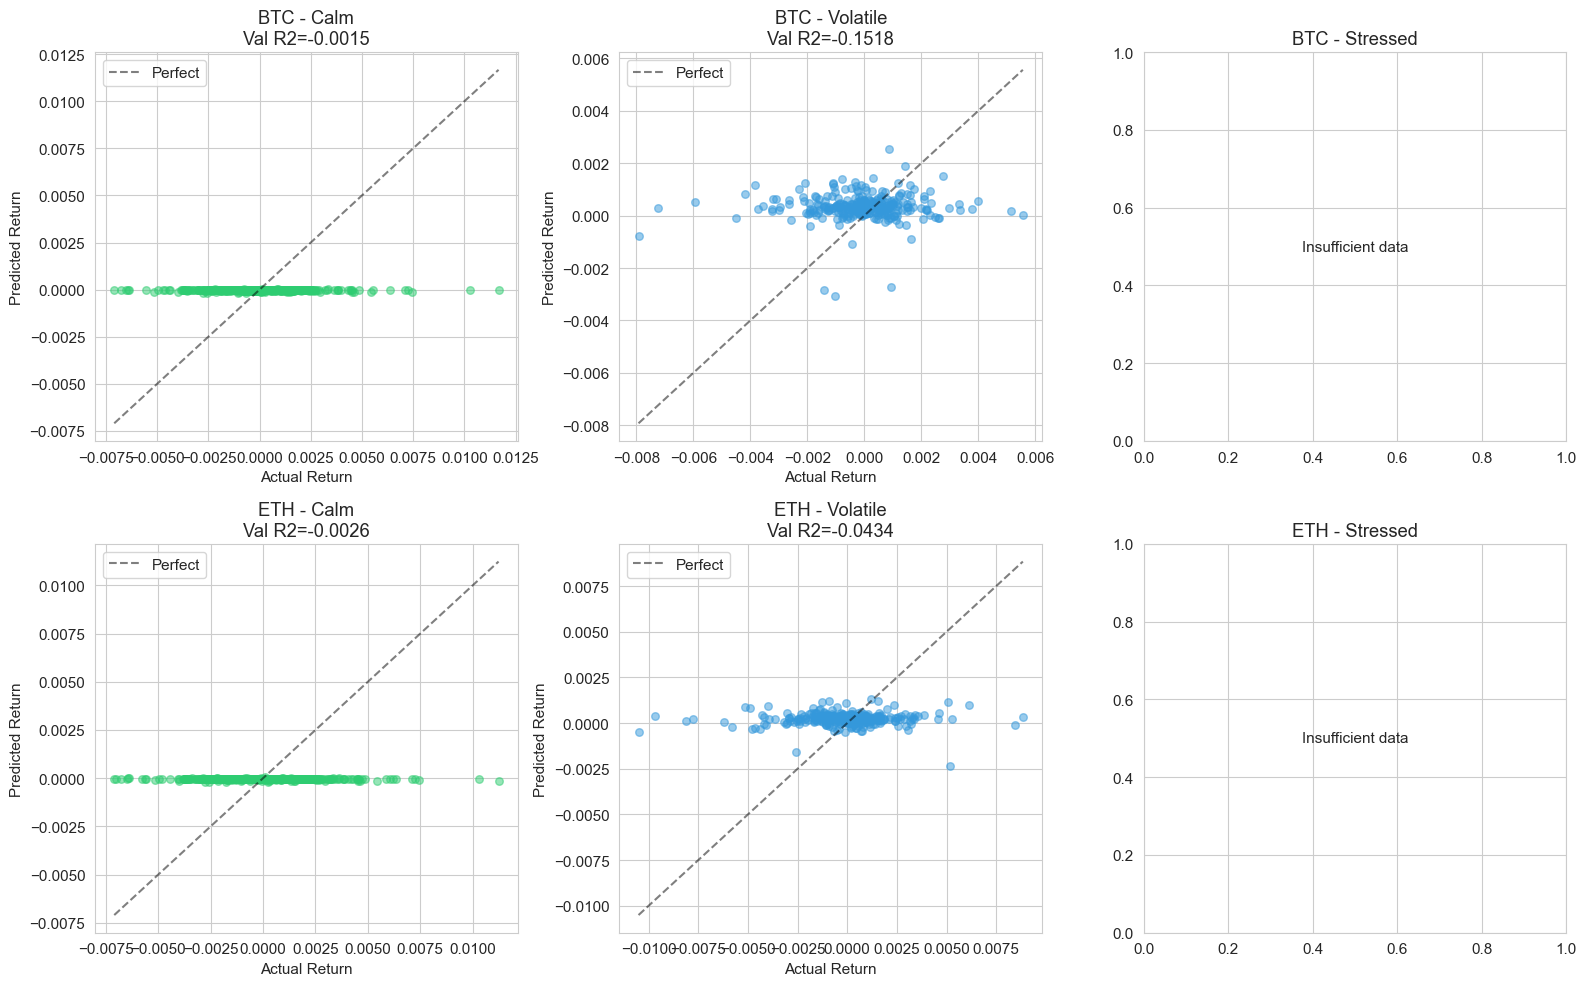

Scatter plots saved to models\lgbm\prediction_scatter.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (asset, X, y) in enumerate([("BTC", X_btc, y_btc), ("ETH", X_eth, y_eth)]):
    for j, regime in enumerate(["Calm", "Volatile", "Stressed"]):
        ax = axes[i * 3 + j]
        
        result = results[asset].get(regime)
        if result is None:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{asset} - {regime}")
            continue
        
        # Get validation data for this regime using 80/20 positional split
        regime_mask = X[f"regime_{regime}"] == 1
        X_r = X[regime_mask]
        y_r = y[regime_mask]
        
        split = int(len(X_r) * 0.8)
        X_val = X_r.iloc[split:]
        y_val = y_r.iloc[split:]
        
        if len(X_val) < 20:
            ax.text(0.5, 0.5, 'Insufficient val data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{asset} - {regime}")
            continue
        
        y_pred = result['model'].predict(X_val)
        
        ax.scatter(y_val, y_pred, alpha=0.5, c=regime_colors[regime], s=30)
        
        # Perfect prediction line
        lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
        ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect')
        
        ax.set_xlabel('Actual Return')
        ax.set_ylabel('Predicted Return')
        ax.set_title(f"{asset} - {regime}\nVal R2={result['val_r2']:.4f}")
        ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prediction_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Scatter plots saved to {OUTPUT_DIR / 'prediction_scatter.png'}")

## 10. Residual Distributions

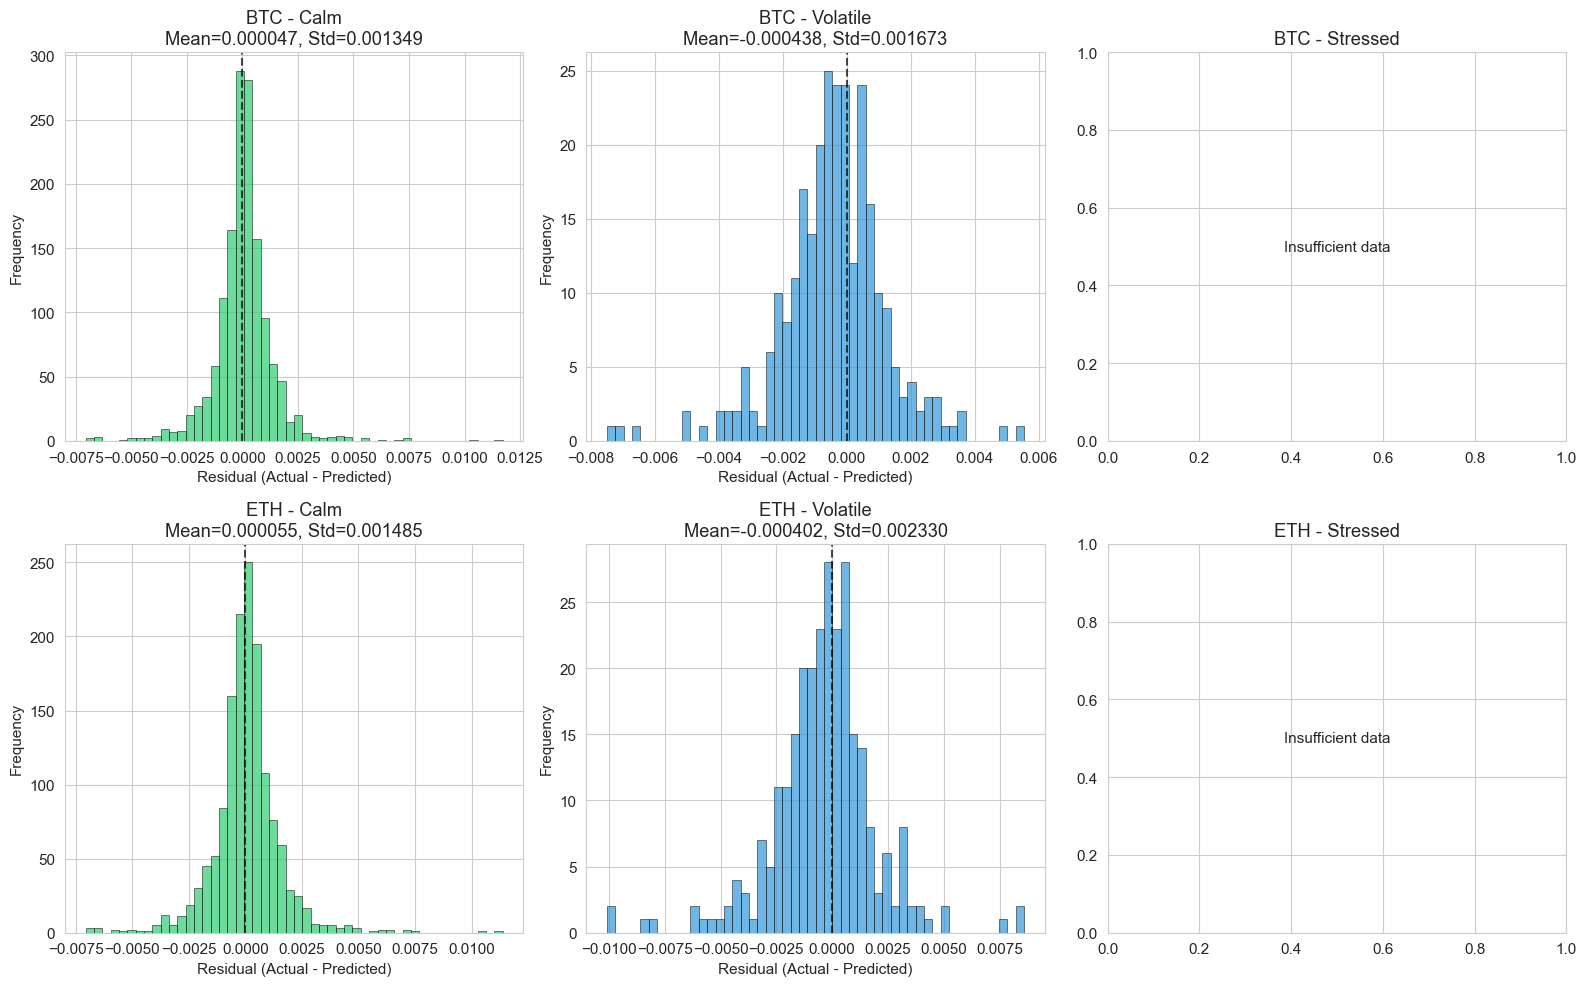

Residual distributions saved to models\lgbm\residual_distributions.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (asset, X, y) in enumerate([("BTC", X_btc, y_btc), ("ETH", X_eth, y_eth)]):
    for j, regime in enumerate(["Calm", "Volatile", "Stressed"]):
        ax = axes[i * 3 + j]
        
        result = results[asset].get(regime)
        if result is None:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{asset} - {regime}")
            continue
        
        regime_mask = X[f"regime_{regime}"] == 1
        X_r = X[regime_mask]
        y_r = y[regime_mask]
        
        split = int(len(X_r) * 0.8)
        X_val = X_r.iloc[split:]
        y_val = y_r.iloc[split:]
        
        if len(X_val) < 20:
            ax.text(0.5, 0.5, 'Insufficient val data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{asset} - {regime}")
            continue
        
        residuals = y_val - result['model'].predict(X_val)
        
        ax.hist(residuals, bins=50, color=regime_colors[regime], alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axvline(0, color='black', linestyle='--', alpha=0.7)
        ax.set_xlabel('Residual (Actual - Predicted)')
        ax.set_ylabel('Frequency')
        ax.set_title(f"{asset} - {regime}\nMean={residuals.mean():.6f}, Std={residuals.std():.6f}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residual_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Residual distributions saved to {OUTPUT_DIR / 'residual_distributions.png'}")

## 11. Summary Table

In [13]:
print("\n" + "="*80)
print("SUMMARY: Regime-Conditional LightGBM Return Forecasting")
print("="*80)

summary_data = []
for asset in ["BTC", "ETH"]:
    for regime in ["Calm", "Volatile", "Stressed"]:
        result = results[asset].get(regime)
        if result:
            summary_data.append({
                'Asset': asset,
                'Regime': regime,
                'Train R2': f"{result['train_r2']:.4f}",
                'Val R2': f"{result['val_r2']:.4f}",
                'Best Iter': result['best_iteration'],
                'N Train': result['n_train'],
                'N Val': result['n_val'],
            })
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(OUTPUT_DIR / 'lgbm_summary.csv', index=False)
print(f"\nSummary saved to {OUTPUT_DIR / 'lgbm_summary.csv'}")


SUMMARY: Regime-Conditional LightGBM Return Forecasting
Asset   Regime Train R2  Val R2  Best Iter  N Train  N Val
  BTC     Calm   0.0056 -0.0015          1     5788   1447
  BTC Volatile   0.0774 -0.1518         37     1104    276
  ETH     Calm   0.0056 -0.0026          1     5788   1447
  ETH Volatile   0.0632 -0.0434         14     1104    276

Summary saved to models\lgbm\lgbm_summary.csv


## 12. Evidence of Regime-Conditional Improvement

In [14]:
# Focus on regime-conditional vs agnostic comparison
print("\n" + "="*70)
print("EVIDENCE: Regime-Conditional vs Regime-Agnostic (Baseline)")
print("="*70)

improvement_summary = []
for asset in ["BTC", "ETH"]:
    print(f"\n{asset}:")
    agnostic_r2 = comparison_results[asset]['agnostic']['val_r2'] if comparison_results[asset]['agnostic'] else float('nan')
    print(f"  Regime-Agnostic (pooled): Val R2 = {agnostic_r2:.4f}")
    
    for regime in ["Calm", "Volatile", "Stressed"]:
        cond_r2 = comparison_results[asset]['conditional'].get(regime, {}).get('val_r2', float('nan'))
        improvement = cond_r2 - agnostic_r2 if not np.isnan(cond_r2) and not np.isnan(agnostic_r2) else 0
        winner = "BETTER" if improvement > 0 else "no improvement"
        print(f"  {regime:10s}: Val R2 = {cond_r2:.4f} (improvement: {improvement:+.4f}) -> {winner}")
        improvement_summary.append({
            'Asset': asset,
            'Regime': regime,
            'Agnostic R2': agnostic_r2,
            'Conditional R2': cond_r2,
            'Improvement': improvement,
        })

improvement_df = pd.DataFrame(improvement_summary)
improvement_df.to_csv(OUTPUT_DIR / 'regime_improvement.csv', index=False)


EVIDENCE: Regime-Conditional vs Regime-Agnostic (Baseline)

BTC:
  Regime-Agnostic (pooled): Val R2 = 0.0015
  Calm      : Val R2 = -0.0015 (improvement: -0.0030) -> no improvement
  Volatile  : Val R2 = -0.1518 (improvement: -0.1533) -> no improvement
  Stressed  : Val R2 = nan (improvement: +0.0000) -> no improvement

ETH:
  Regime-Agnostic (pooled): Val R2 = -0.0026
  Calm      : Val R2 = -0.0026 (improvement: +0.0001) -> BETTER
  Volatile  : Val R2 = -0.0434 (improvement: -0.0408) -> no improvement
  Stressed  : Val R2 = nan (improvement: +0.0000) -> no improvement


In [15]:
# Verify saved models
print("\nSaved model files:")
for f in sorted(OUTPUT_DIR.glob("lgbm_*.pkl")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name} ({size_kb:.1f} KB)")


Saved model files:
  lgbm_btc_calm.pkl (8.8 KB)
  lgbm_btc_volatile.pkl (117.1 KB)
  lgbm_eth_calm.pkl (8.8 KB)
  lgbm_eth_volatile.pkl (47.7 KB)


In [16]:
print(f"\n{'='*70}")
print(f"NOTEBOOK EXECUTION COMPLETE")
print(f"{'='*70}")
print(f"Data source: {'SYNTHETIC' if USING_SYNTHETIC_DATA else 'REAL'}")
print(f"Models saved to: {OUTPUT_DIR}")
print(f"Charts saved to: {OUTPUT_DIR}")
print(f"\nTo re-run with real data once available:")
print(f"  1. Ensure data/processed/ contains price_features.parquet and trades_processed.parquet")
print(f"  2. Ensure models/hmm/regime_labels.csv exists")
print(f"  3. Re-execute this notebook")


NOTEBOOK EXECUTION COMPLETE
Data source: REAL
Models saved to: models\lgbm
Charts saved to: models\lgbm

To re-run with real data once available:
  1. Ensure data/processed/ contains price_features.parquet and trades_processed.parquet
  2. Ensure models/hmm/regime_labels.csv exists
  3. Re-execute this notebook
